In [ ]:
!pip install lime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss

In [ ]:
df = pd.read_csv("email.csv")
df

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...
...,...,...,...,...,...,...,...,...,...,...,...
781810,{E4A7-K0YN86DN-2389ECKD},05/20/2010 11:16:27,IIW0249,PC-0843,Glass-Matthew@aol.com,Igor.I.Ward@comcast.net,NaN,Igor.I.Ward@comcast.net,30117,0,thry quoted twelve among has each towed rule d...
781811,{O4E4-V0BX75OT-8883YMAG},05/20/2010 11:16:27,MES0407,PC-8827,Herman.Ian.Abbott@dtaa.com,NaN,NaN,Minerva.Emerald.Solomon@dtaa.com,35875,0,called craftsmen build thomas damaged stored e...
781812,{U6M5-A0SA71DG-5475AXIA},05/20/2010 11:16:29,CSB0080,PC-0731,Bryar_Sweet@bellsouth.net,NaN,NaN,Catherine_Bullock@comcast.net,22351,0,hence major perpendicular peculiar synonymousl...
781813,{P1S0-W2IC21HR-6253JZFH},05/20/2010 11:16:32,CCR0863,PC-7342,Zeph_Wilkerson@yahoo.com,NaN,NaN,Charde_Rasmussen@sbcglobal.net,39317,0,late distant york normal according colonies de...


Preprocessing

In [ ]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Fill missing vals
df.fillna('', inplace=True)

In [ ]:
le = LabelEncoder()
for col in ['user', 'pc', 'to', 'cc', 'bcc', 'from']:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,588,553,57273,41257,0,1239,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,675,665,168748,0,0,1258,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,588,553,173967,0,0,1240,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,588,553,119644,0,0,1240,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,675,665,27890,0,444,1258,17319,0,this kmh october holliswood number advised unu...


In [ ]:
# Feature Engineering from 'date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# feature selection
df.drop(columns=['date', 'to', 'cc', 'from'], inplace=True)


In [ ]:
# Create a label based on 'bcc' and 'size' as suspicious
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['size'] = df['size'].fillna(0)
df['is_malicious'] = ((df['bcc'].astype(str).astype(int) > 0) & (df['size'] > 50000)).astype(int)

print(df['is_malicious'].value_counts())

is_malicious
0    776605
1      5210
Name: count, dtype: int64


In [ ]:
features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
features.remove('is_malicious')

X = df[features]
y = df['is_malicious']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

EDA

In [ ]:
# Handle outliers using Z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).all(axis=1)  # Identify outliers (Z-score > 3)
print(f"Number of outlier rows: {outliers.sum()}")



Number of outlier rows: 0


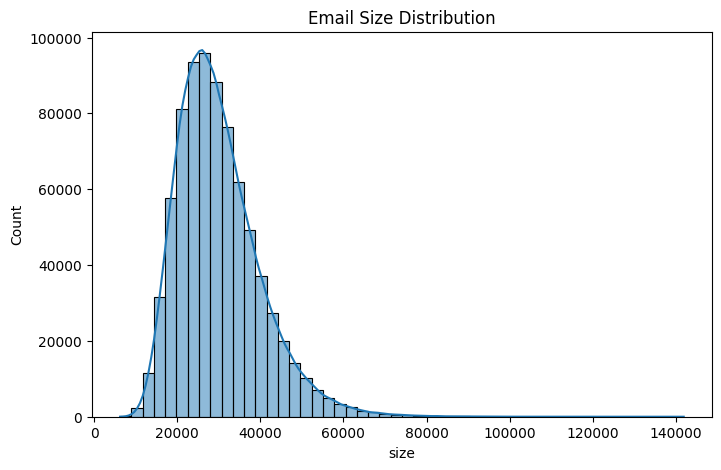

In [ ]:
#size dist
plt.figure(figsize=(8,5))
sns.histplot(df['size'], bins=50, kde=True)
plt.title("Email Size Distribution")
plt.show()


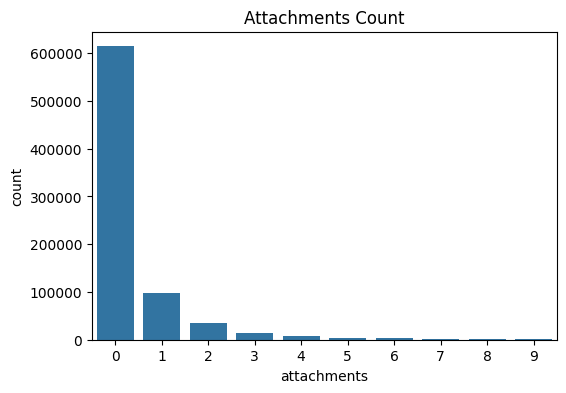

In [ ]:
#Num ofattachments
plt.figure(figsize=(6,4))
sns.countplot(x='attachments', data=df)
plt.title("Attachments Count")
plt.show()


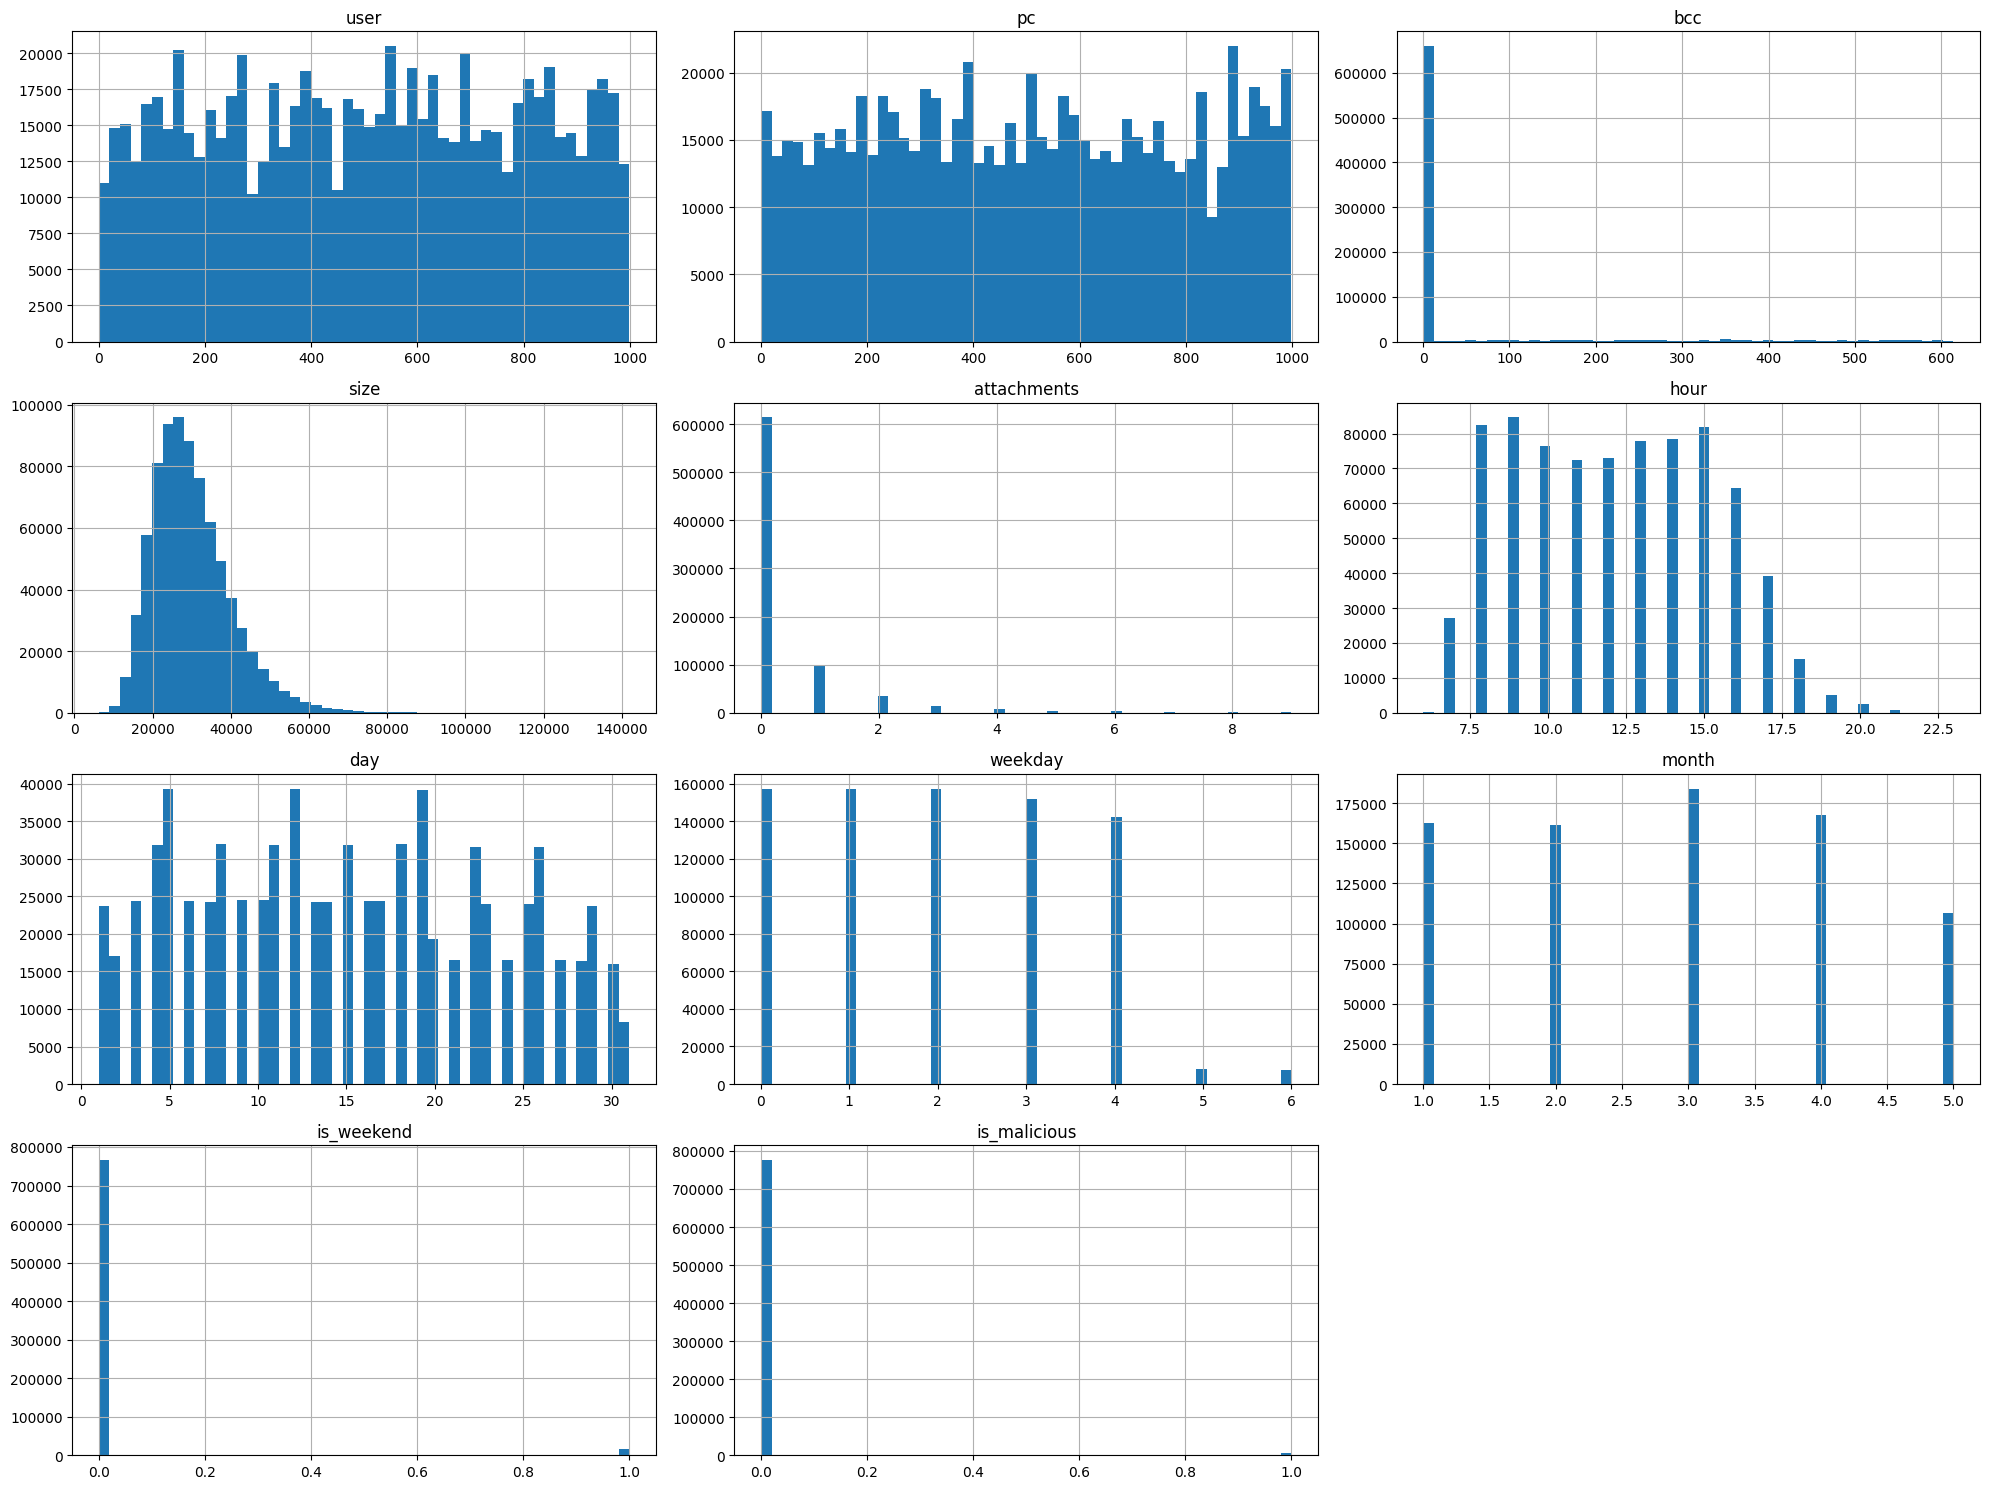

In [ ]:
df.hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

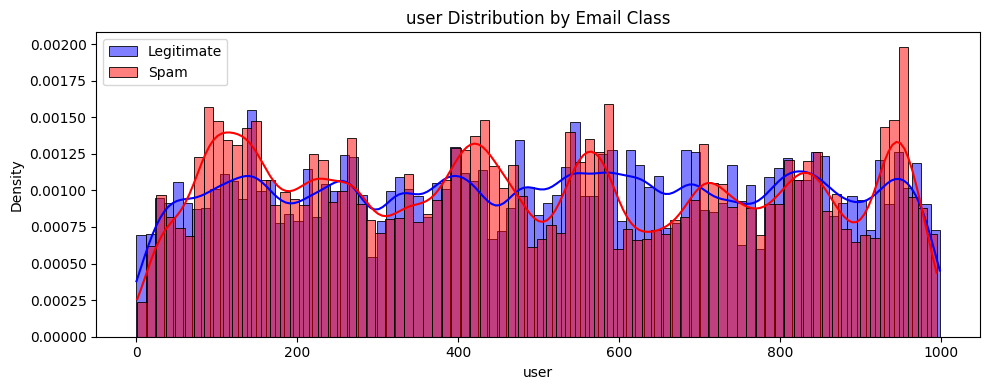

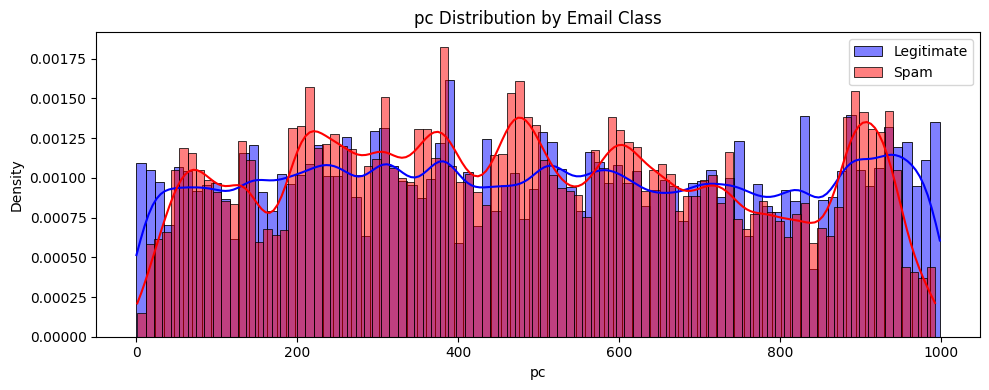

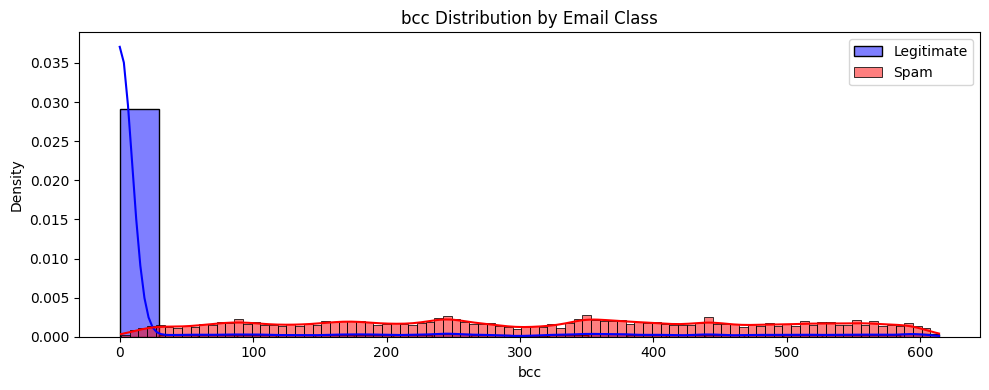

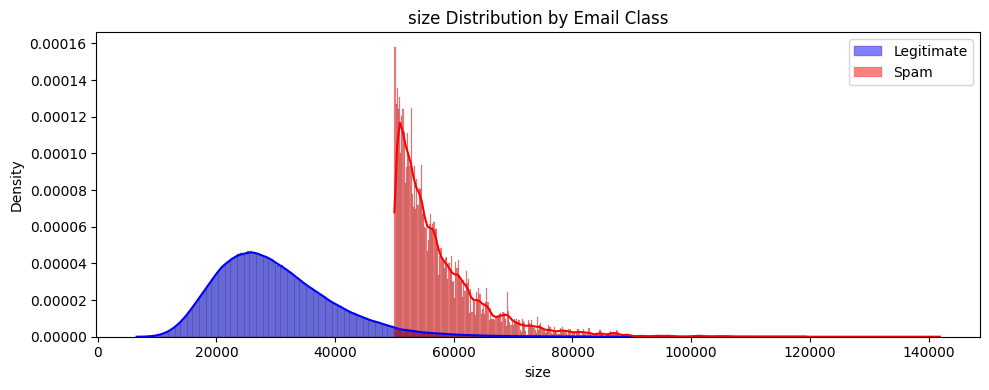

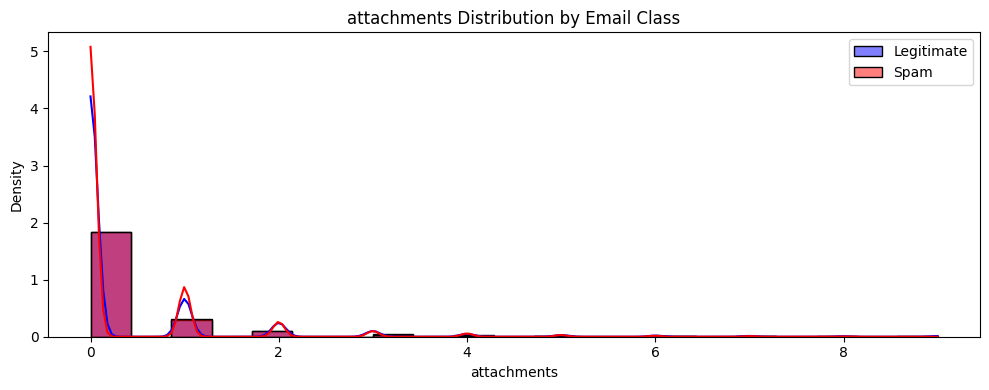

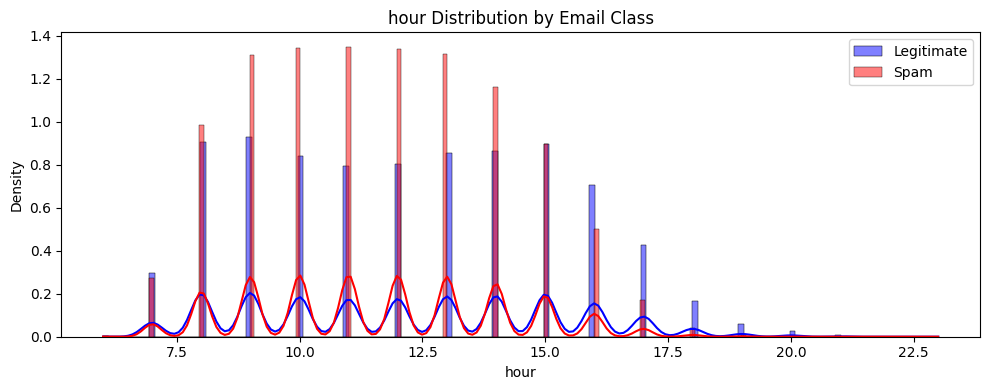

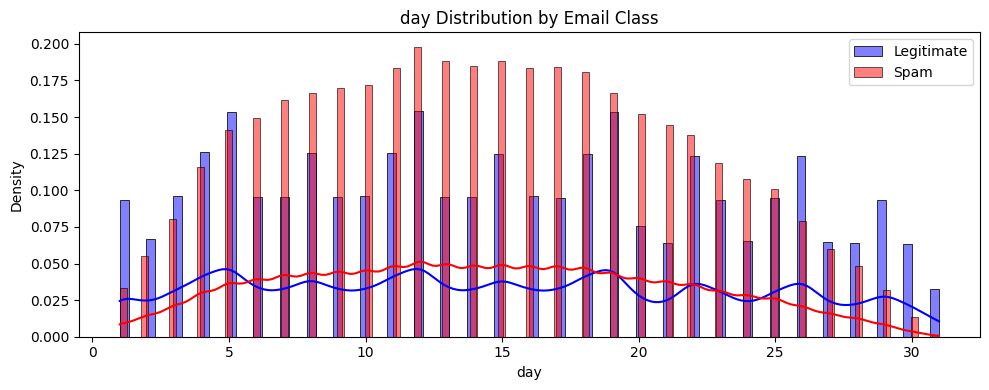

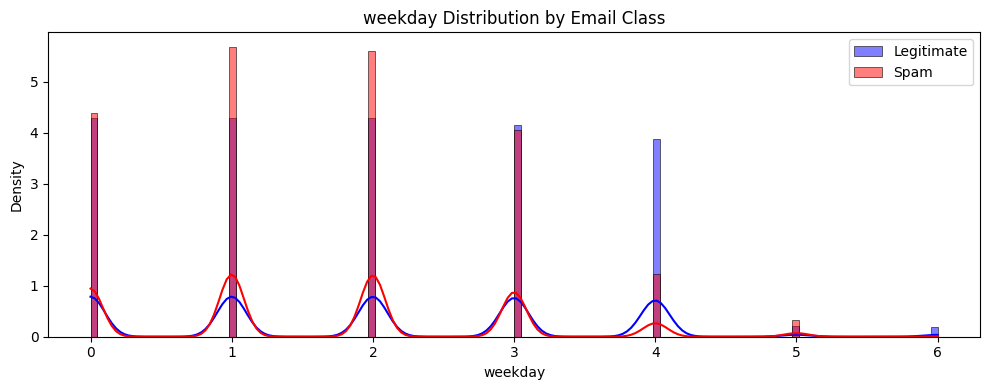

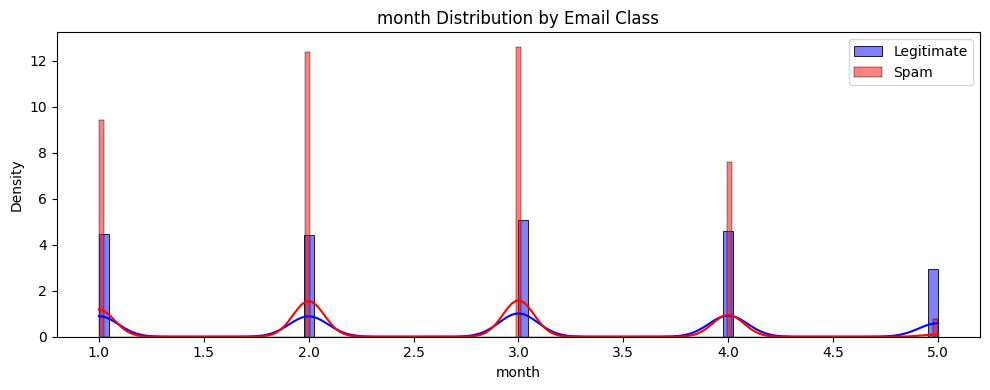

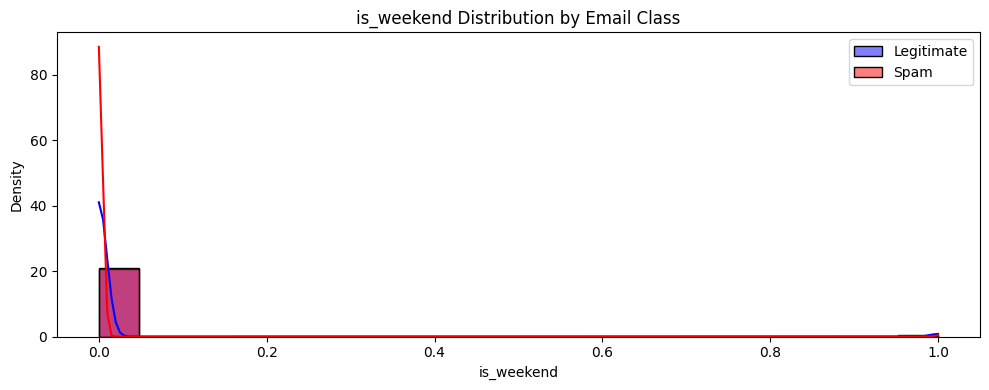

In [ ]:
for feature in X_resampled.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(X_resampled[feature][y_resampled == 0], color="blue", label="Legitimate", kde=True, stat="density")
    sns.histplot(X_resampled[feature][y_resampled == 1], color="red", label="Spam", kde=True, stat="density")
    plt.title(f'{feature} Distribution by Email Class')
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


KNN Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

In [ ]:
knn = KNeighborsClassifier(n_neighbors=10)
cv_scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy:", test_accuracy)

Cross-validation scores: [0.99769769 0.99819333 0.99768167 0.99756975 0.99752178 0.9977776
 0.99779359 0.99800144 0.9975058  0.9977776 ]
Mean CV accuracy: 0.9977520251162776
Test set accuracy: 0.9979662707929625


In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[155350      3]
 [   315    695]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    155353
           1       1.00      0.69      0.81      1010

    accuracy                           1.00    156363
   macro avg       1.00      0.84      0.91    156363
weighted avg       1.00      1.00      1.00    156363



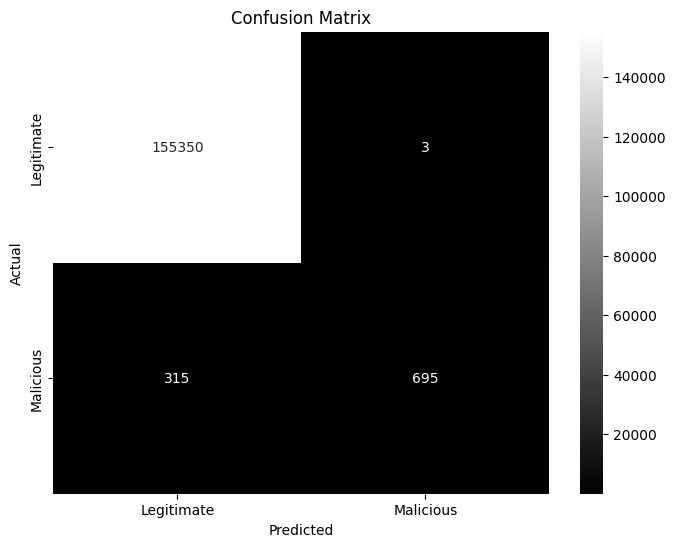

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="gray",
            xticklabels=['Legitimate', 'Malicious'],
            yticklabels=['Legitimate', 'Malicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


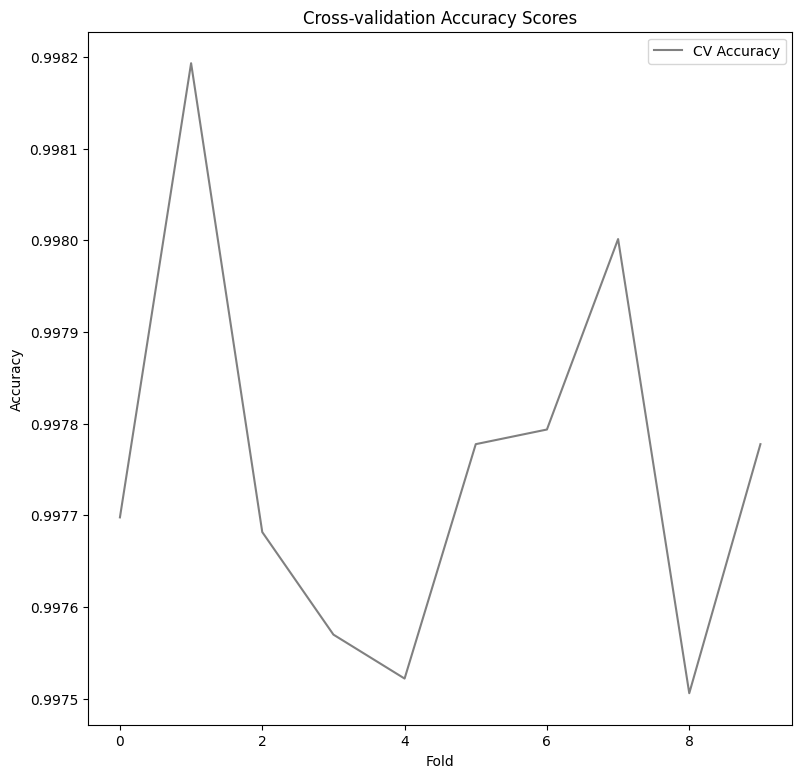

In [ ]:
plt.figure(figsize=(20, 9))
plt.subplot(1, 2, 1)
plt.plot(cv_scores, label='CV Accuracy', color='gray')
plt.title('Cross-validation Accuracy Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()


Explainability techniques

Lime

In [ ]:
## Prepare LIME Explainer
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X_train.values,
                                 feature_names=X_train.columns,
                                 class_names=['Benign', 'Threat'],
                                 discretize_continuous=True)

i =31
exp = explainer.explain_instance(data_row=X_test.iloc[i].values,predict_fn=knn.predict_proba)
exp.show_in_notebook()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


This LIME output is explaining why the classifier has classified the email as Benign with 100% confidence. It is saying that features like no BCC recipients (bcc = 0), large email size (size = 16749), and large user count (user = 509) are strong predictors of the "Benign" class. Although some features like the number of PCs contacted (pc = 92), sending hour (hour = 9), and zero attachments do work in favor of the "Threat" class, their influence is much weaker. The prediction is dominated overall by strong indications of benign behavior.


In [ ]:
def get_examples_per_class(X, y):
    examples = {}
    for i in range(len(y)):
        label = y.iloc[i] if hasattr(y, "iloc") else y[i]
        if label not in examples:
            examples[label] = X.iloc[i]
        if len(examples) == 2:
            break
    return examples
examples = get_examples_per_class(X_test, y_test)

In [ ]:
for label, example in examples.items():
    print(f"Explaining example from class: {label}")
    exp = explainer.explain_instance(
        data_row=example.values,
        predict_fn=knn.predict_proba,
        num_features=10
    )
    exp.show_in_notebook()

Explaining example from class: 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Explaining example from class: 1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


This LIME outcome explains how the machine learning model classifies input data into two categories: "Design" and "Threat." The tables present the rules of the model used for determining each category. For example, if "Bongo" is 1.00, it strongly suggests "Design," while conditions such as "user > 354.00" or "month <= 3.00" help forecast "Threat." The "Feature Value" column holds real input values to be tested, e.g., "day: 16.00" or "user: 355.00," which are compared with the rules of the model to determine the classification. Warnings are technical issues but do not affect the overall meaning. In effect, LIME determines which features and values contributed to the model's prediction.



Shap

In [ ]:
import shap

  0%|          | 0/10 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

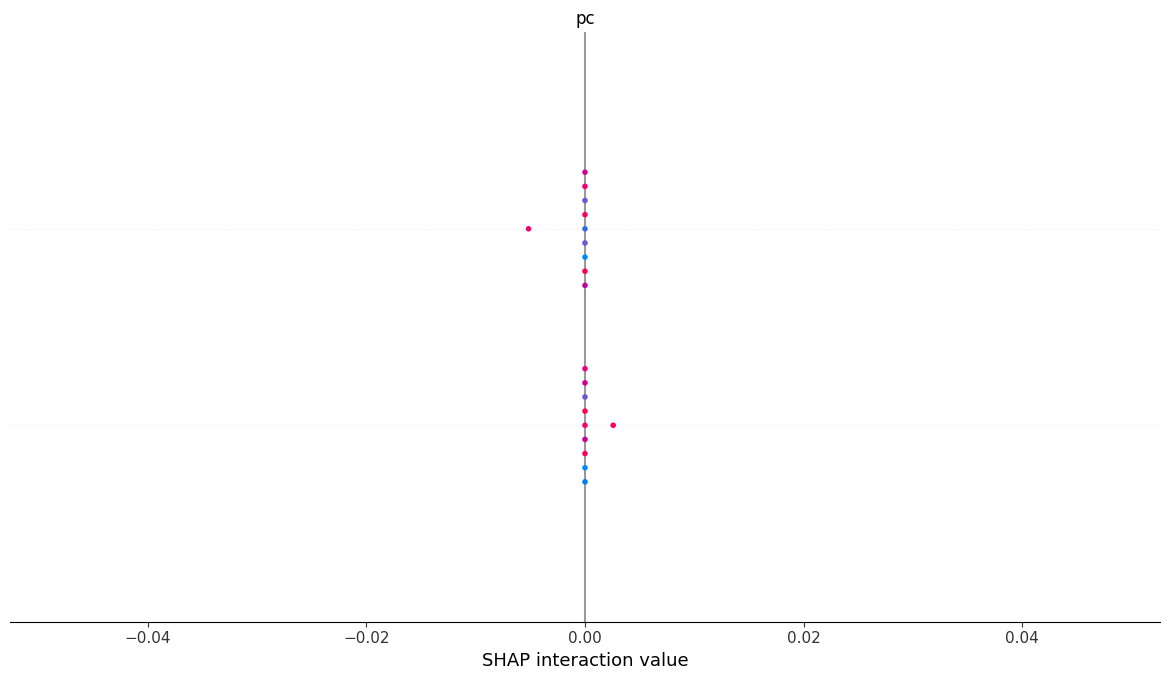

In [ ]:
test_images = X_test.iloc[np.random.choice(X_test.shape[0], 10, replace=False)]
background = X_train.iloc[np.random.choice(X_train.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(knn.predict_proba, background)
shap_values = explainer.shap_values(test_images)
shap.summary_plot(shap_values, test_images)

This plot illustrates SHAP interaction values for a single feature named "PC," and it illustrates how interactions with other features influence the model prediction. The direction and magnitude of these interactions are on the x-axis, with positive up to 0.04 values indicating the interaction increases the prediction score and negative down to -0.04 decreases the prediction score. The short range of values indicates that these interactions yield small but real impacts to the output of the model. As this is a single plot presented, "PC" likely means a dominant aspect or large part whose overall effect with other parameters subtly influences the predictions. The visualization decodes these implicit correlations, which point to feature interdependencies governing the decision-making mechanism of the model. For full context.

LOFO

In [ ]:
baseline = cross_val_score(knn, X_train, y_train, cv=5).mean()

lofo_scores = {}
for col in X_train.columns:
    X_lofo = X_train.drop(columns=[col])
    score = cross_val_score(knn, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score

lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)

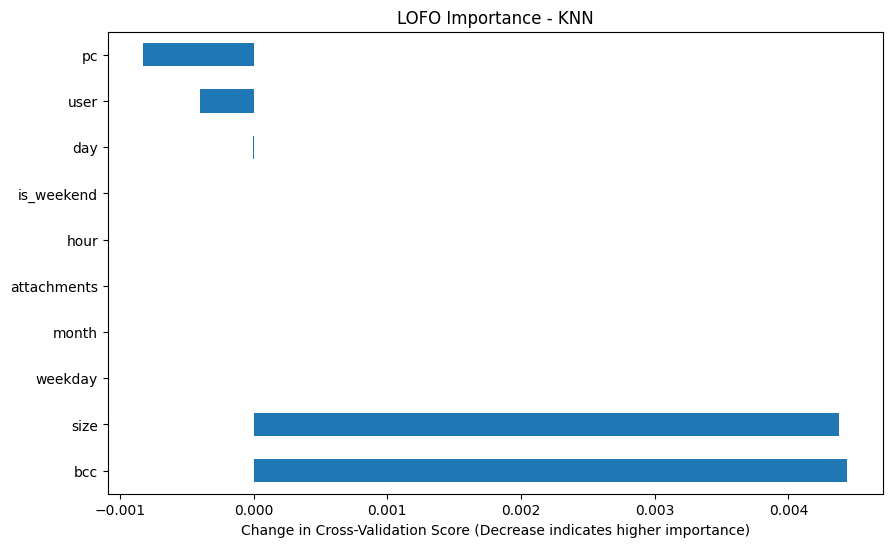

In [ ]:
lofo_df.plot(kind='barh', figsize=(10, 6))
plt.title("LOFO Importance - KNN")
plt.xlabel("Change in Cross-Validation Score (Decrease indicates higher importance)")
plt.show()

This chart tells us which of the features are most important to the accuracy of the KNN model according to LOFO analysis. The features that are further to the left on the axis are the most important - their elimination would be harmful to the accuracy of the model. "pc" is discovered here to be the most important factor, whereas others like "user" and "day" have minimal impact when they are eliminated. The restricted value range (all near to zero) ensures that it is impossible for most features to provide a meaningful contribution to the performance of the model on their own. This helps in selecting features which contribute to something in the predictions of the model.

ICE

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
subset_X_train = X_train.sample(n=1000, random_state=42)

/usr/local/lib/python3.11/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


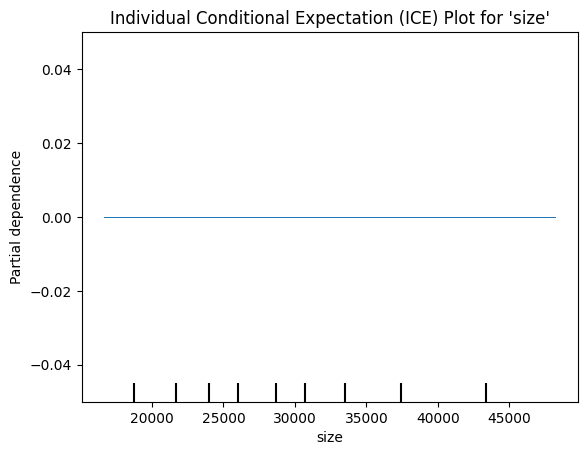

In [ ]:
# ICE plot for 'size' feature
PartialDependenceDisplay.from_estimator(knn, subset_X_train, ['size'], kind='individual', grid_resolution=50)
plt.title("Individual Conditional Expectation (ICE) Plot for 'size'")
plt.show()

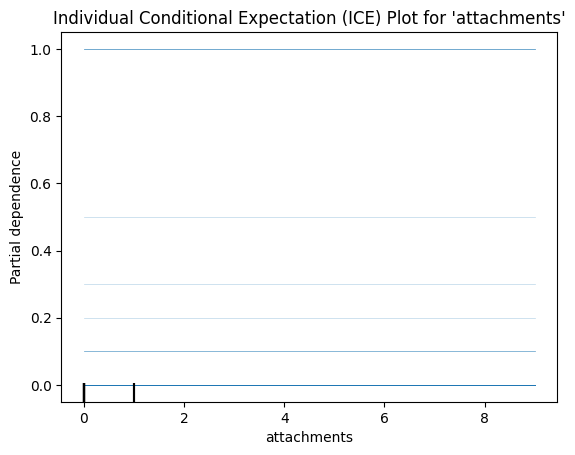

In [ ]:
# ICE plot for 'attachments' feature
PartialDependenceDisplay.from_estimator(knn, subset_X_train, ['attachments'], kind='individual', grid_resolution=50)
plt.title("Individual Conditional Expectation (ICE) Plot for 'attachments'")
plt.show()

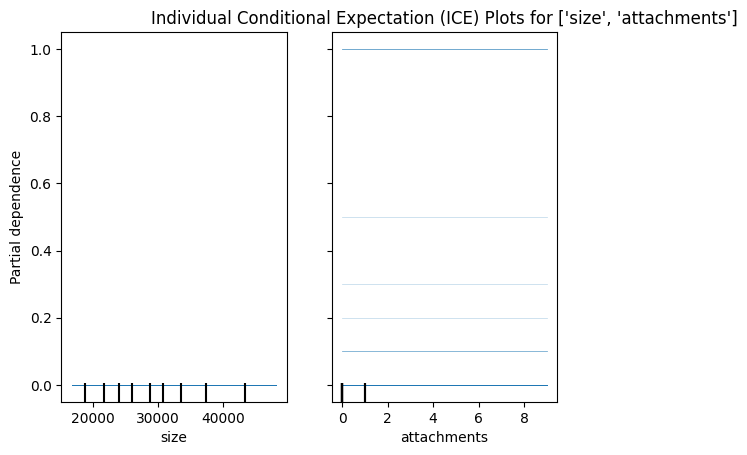

In [ ]:
# ICE plot for multiple features (e.g., 'size' and 'attachments')
features_for_ICE = ['size', 'attachments']
PartialDependenceDisplay.from_estimator(knn, subset_X_train, features_for_ICE, kind='individual', grid_resolution=50)
plt.title(f"Individual Conditional Expectation (ICE) Plots for {features_for_ICE}")
plt.show()


These ICE (Individual Conditional Expectation) plots are used to show the effect of variation in features 'size' and 'attachments' on the predictions of the model. From the 'size' plot, it is clear that the predictions are quite consistent for variations in sizes (20,000 to 45,000), with barely any variation in partial dependence values varying from -0.04 to 0.04. The 'attachments' plot illustrates a more local pattern: the number of attachments between 0 and 8, and the predicted value decreasing monotonically from about 1.0 to 0.0. Both features are shown side by side in the joint plot, and it is easy to see their different effects - 'attachments' has a much stronger and deterministic effect on the model value than 'size'. These visualizations also indicate exactly how each feature is utilized within the model's conclusions.